In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import joblib

In [4]:
df = pd.read_csv('Churn_Modelling.csv')
df.sample(3)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
447,448,15644572,Turnbull,501,France,Male,40,4,125832.20,1,1,1,100433.83,0
7770,7771,15809509,Venables,699,France,Male,29,3,125689.29,1,1,1,151623.71,0
7466,7467,15586174,Brodney,700,Germany,Female,30,4,116377.48,1,1,1,134417.31,0


In [5]:
df.drop(columns=['RowNumber','CustomerId','Surname'],inplace=True)

In [6]:
df=pd.get_dummies(df,columns=['Geography','Gender'],drop_first=True)
df.sample(5)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
4559,528,62,7,133201.17,1,0,0,168507.68,1,True,False,False
6617,678,54,1,123699.28,2,0,1,105221.76,0,True,False,False
2507,653,33,1,0.00,2,0,0,53379.52,0,False,False,True
1126,663,33,8,122528.18,1,1,0,196260.30,0,False,True,False
7950,516,33,10,138847.90,1,1,1,127256.70,0,True,False,False


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CreditScore        10000 non-null  int64  
 1   Age                10000 non-null  int64  
 2   Tenure             10000 non-null  int64  
 3   Balance            10000 non-null  float64
 4   NumOfProducts      10000 non-null  int64  
 5   HasCrCard          10000 non-null  int64  
 6   IsActiveMember     10000 non-null  int64  
 7   EstimatedSalary    10000 non-null  float64
 8   Exited             10000 non-null  int64  
 9   Geography_Germany  10000 non-null  bool   
 10  Geography_Spain    10000 non-null  bool   
 11  Gender_Male        10000 non-null  bool   
dtypes: bool(3), float64(2), int64(7)
memory usage: 732.6 KB


In [8]:
def map_bools(df):
    for col in df.columns:
        if df[col].dtype == 'bool':
            df[col] = df[col].map({True: 1, False: 0})
    return df

df = map_bools(df)


In [29]:
df.sample(3)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
9290,850,33,8,73059.38,1,1,1,186281.00,0,0,0,1
1164,850,36,0,164850.54,1,1,1,62722.44,0,0,0,0
3626,789,37,6,110689.07,1,1,1,71121.04,1,1,0,0


In [10]:
x=df.drop(columns=['Exited'])
y=df['Exited']

In [11]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=23)

In [12]:
sc=StandardScaler()
x_train_scaled=sc.fit_transform(x_train)
x_test_scaled=sc.transform(x_test)

In [13]:
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense

In [14]:
model=Sequential()

model.add(Dense(11, activation='relu', input_dim=11))
model.add(Dense(20, activation='relu'))
model.add(Dense(11, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
his=model.fit(x_train_scaled, y_train, epochs=30,validation_split=0.2)

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7928 - loss: 0.5395 - val_accuracy: 0.8000 - val_loss: 0.4809
Epoch 2/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7984 - loss: 0.4631 - val_accuracy: 0.8056 - val_loss: 0.4411
Epoch 3/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8073 - loss: 0.4387 - val_accuracy: 0.8094 - val_loss: 0.4298
Epoch 4/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8119 - loss: 0.4291 - val_accuracy: 0.8188 - val_loss: 0.4243
Epoch 5/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8177 - loss: 0.4217 - val_accuracy: 0.8206 - val_loss: 0.4202
Epoch 6/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8244 - loss: 0.4142 - val_accuracy: 0.8250 - val_loss: 0.4136
Epoch 7/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8311 - loss: 0.4040 - val_accuracy: 0.8325 - val_loss: 0.4047
Epoch 8/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8352 - loss: 0.3907 - val_accuracy: 0.8381 - val_

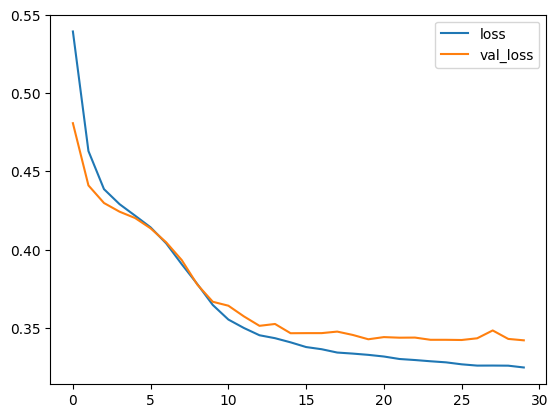

In [15]:
plt.plot(his.history['loss'],label='loss')
plt.plot(his.history['val_loss'],label='val_loss')
plt.legend()

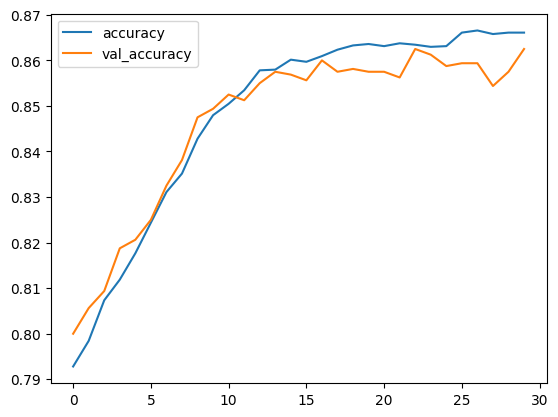

In [16]:
plt.plot(his.history['accuracy'],label='accuracy')
plt.plot(his.history['val_accuracy'],label='val_accuracy')
plt.legend()

In [17]:
y_predict=np.where(model.predict(x_test_scaled)>0.5,1,0)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [18]:
acc=accuracy_score(y_test,y_predict)
acc

0.862

In [34]:
input=[789,37,6,110689.07,1,1,1,71121.04,1,0,0]

input_df = pd.DataFrame([input], columns=x.columns)
input_scaled = sc.transform(input_df)

result=model.predict(input_scaled)
if result[0]<0.5:
    print('Customer will not leave the bank')
    print("probability to leave the bank :",result[0])
else:
    print('Customer will leave the bank')
    print("probability to leave the bank :",result[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
Customer will not leave the bank
probability to leave the bank : [0.29584625]
